#Fashin MNIST
Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

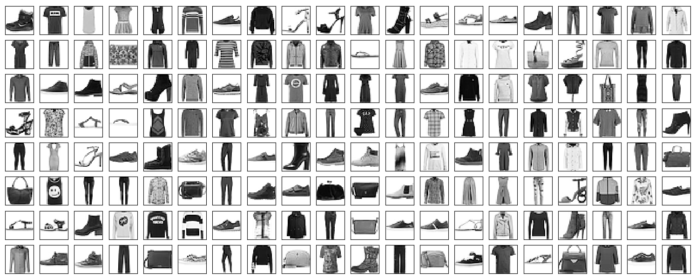


In [1]:
from tensorflow.keras import datasets, layers, models, utils
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train2d, y_train),(x_test2d, y_test) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(x_train2d.shape, y_train.shape)
print(x_test2d.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [4]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

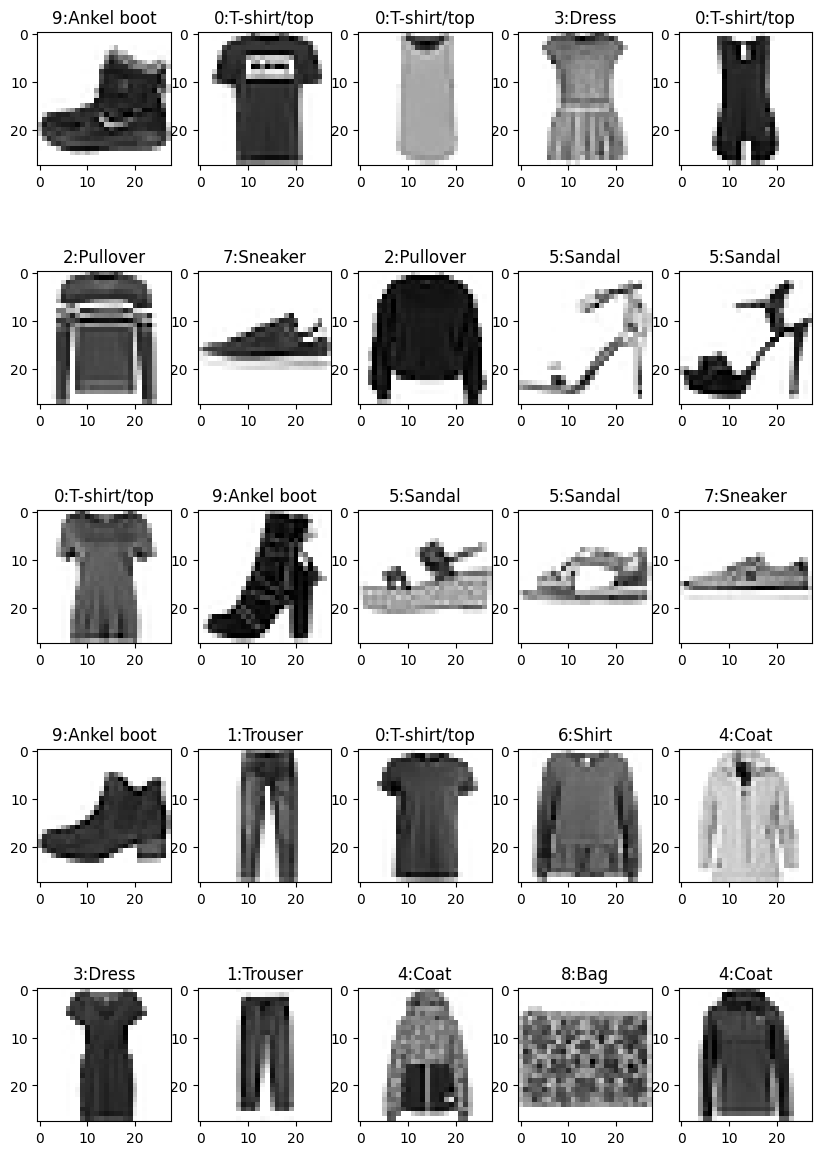

In [5]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_train[i*5+j], items[y_train[i*5+j]]))
    axs[i, j].imshow(x_train2d[i*5+j], cmap='gray_r')
plt.show()

In [6]:
x_train = x_train2d.reshape(-1, 28, 28, 1) #채널추가(1:단색, 3:컬러(rgb))
x_test = x_test2d.reshape(-1, 28, 28, 1)

In [7]:
x_train = x_train / 255                   #정규화
x_test = x_test / 255

#모델구성

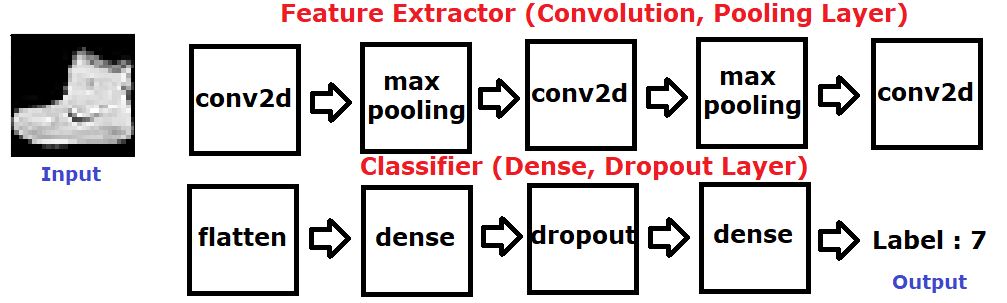

## Feature Extractor

In [23]:
model = models.Sequential() #32->64->128
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2,2), strides=2))          #(2,2):뒤쪽 2랑 strides(2)랑 같아야 한다.
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2), strides=2))
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

### Classifier

In [24]:
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc']) #sparse_categorical_crossentropy 가 one-hot encoding을 해준다.

In [26]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - acc: 0.8463 - loss: 0.4192 - val_acc: 0.8932 - val_loss: 0.2869
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - acc: 0.9017 - loss: 0.2660 - val_acc: 0.9108 - val_loss: 0.2483
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - acc: 0.9197 - loss: 0.2196 - val_acc: 0.9160 - val_loss: 0.2371
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9311 - loss: 0.1845 - val_acc: 0.9216 - val_loss: 0.2278
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9422 - loss: 0.1557 - val_acc: 0.9217 - val_loss: 0.2316
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9514 - loss: 0.1312 - val_acc: 0.9133 - val_loss: 0.2522
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9600 - loss: 0.1054 - val_acc: 0.9218 - val_loss: 0.2411
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9684 - loss: 0.0847 - val_acc: 0.9190 - val_loss: 0.2782
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━

In [21]:
def plot_history(history):
  plt.figure(figsize=(15,5))
  plt.subplot(1,2,1)
  plt.plot(history['acc'])
  plt.plot(history['val_acc'])
  plt.legend(['train','validation'])
  plt.title('Acc')

  plt.subplot(1,2,2)
  plt.plot(history['loss'])
  plt.plot(history['val_loss'])
  plt.legend(['train','validation'])
  plt.title('Loss')

  plt.show()

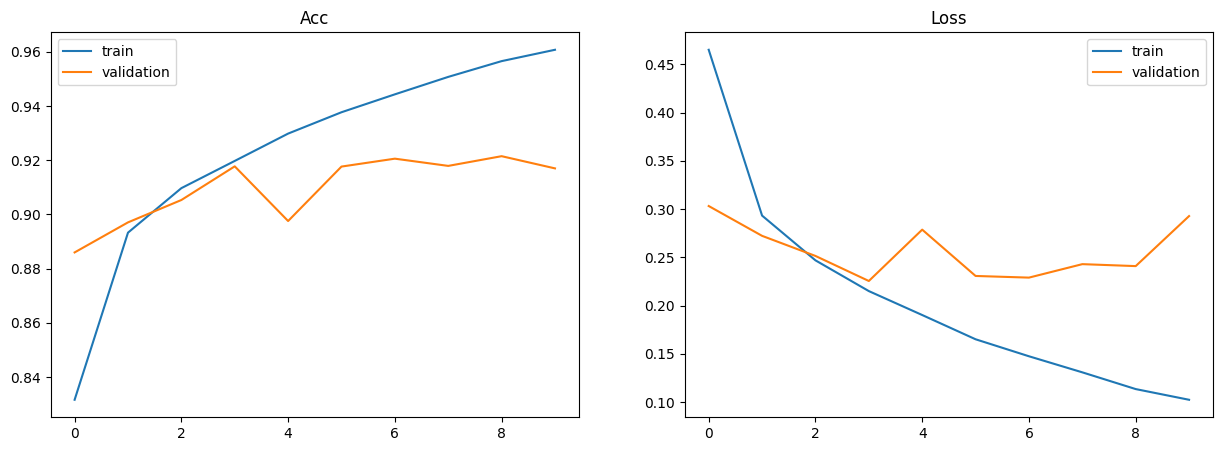

In [22]:
plot_history(history.history)

#Drop out
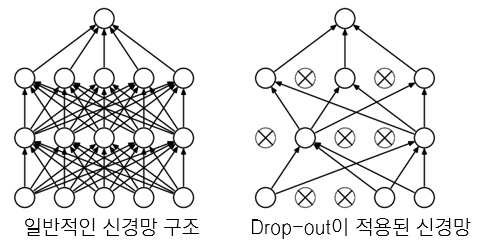

In [29]:
model1 = models.Sequential() #32->64->128
model1.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)))
model1.add(layers.MaxPooling2D((2,2), strides=2))          #(2,2):뒤쪽 2랑 strides(2)랑 같아야 한다.
model1.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model1.add(layers.MaxPooling2D((2,2), strides=2))
model1.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model1.add(layers.Flatten())
model1.add(layers.Dense(128, activation='relu'))
model1.add(layers.Dropout(0.3))
model1.add(layers.Dense(10, activation='softmax'))
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc']) #sparse_categorical_crossentropy 가 one-hot encoding을 해준다.

In [35]:
history1 = model1.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.8346 - loss: 0.4516 - val_acc: 0.8849 - val_loss: 0.3165
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.8937 - loss: 0.2901 - val_acc: 0.9042 - val_loss: 0.2659
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9104 - loss: 0.2428 - val_acc: 0.9135 - val_loss: 0.2331
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9216 - loss: 0.2114 - val_acc: 0.9151 - val_loss: 0.2335
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9319 - loss: 0.1833 - val_acc: 0.9176 - val_loss: 0.2366
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9405 - loss: 0.1596 - val_acc: 0.9203 - val_loss: 0.2246
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9490 - loss: 0.1376 - val_acc: 0.9212 - val_loss: 0.2386
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9549 - loss: 0.1208 - val_acc: 0.9175 - val_loss: 0.2678
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━

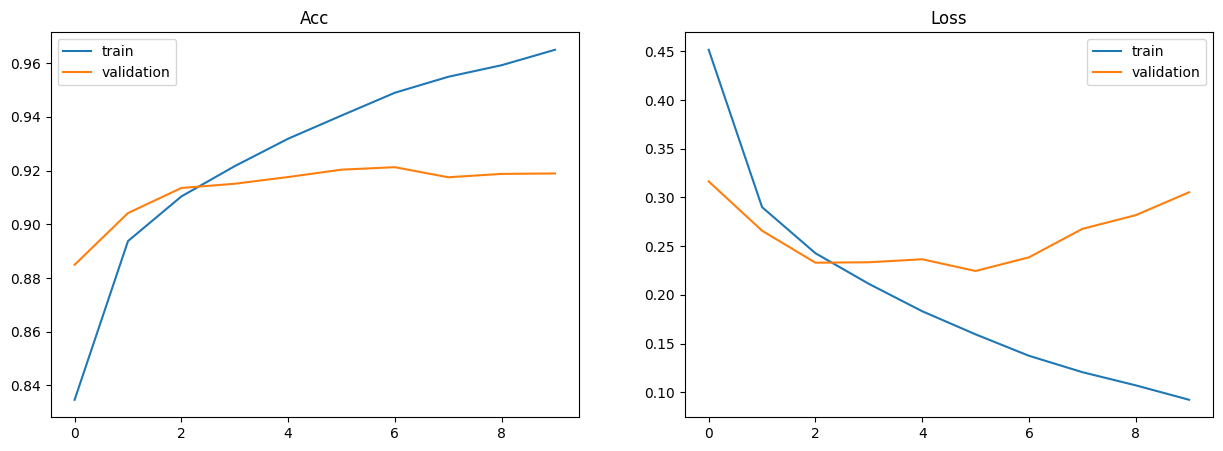

In [36]:
plot_history(history1.history)

## BatchNormalization
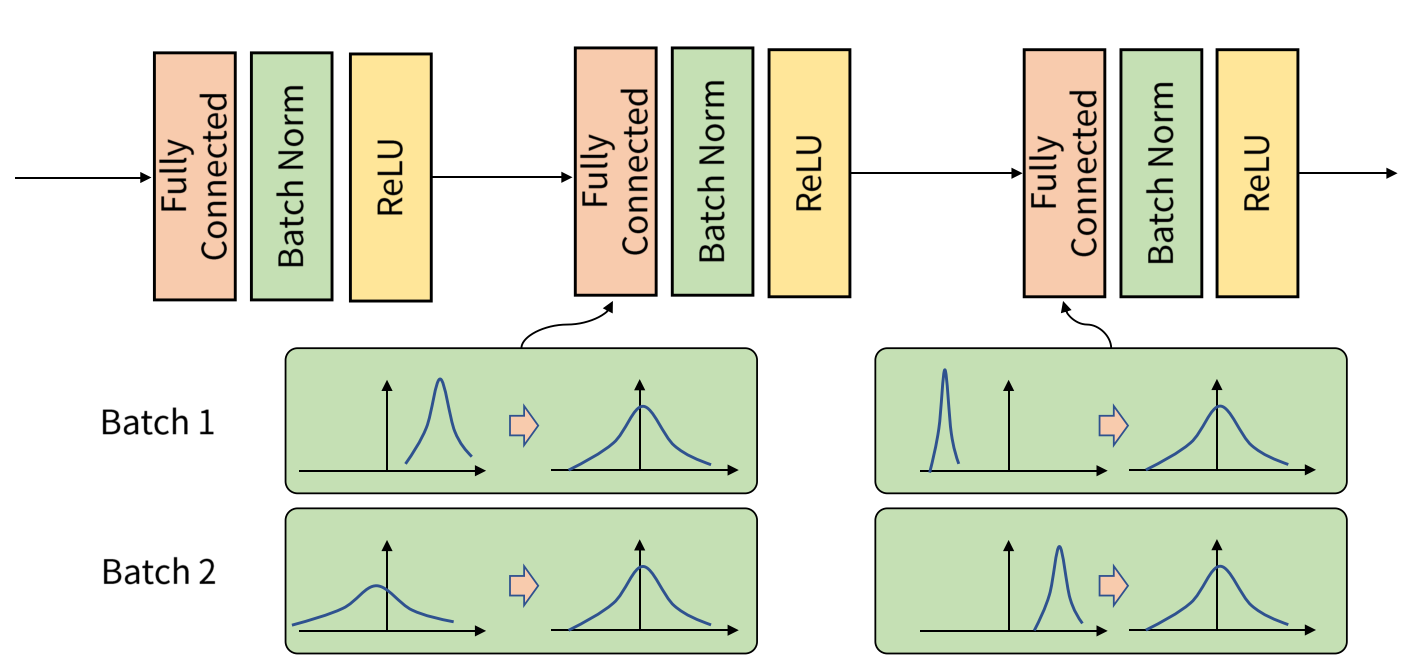

In [27]:
model2 = models.Sequential()
model2.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)))
model2.add(layers.BatchNormalization())  #과적합 방지
model2.add(layers.MaxPooling2D((2,2), strides=2))
model2.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2,2), strides=2))
model2.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model2.add(layers.Flatten())
model2.add(layers.Dense(128, activation='relu'))
model2.add(layers.Dropout(0.3))
model2.add(layers.Dense(10, activation='softmax'))
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [31]:
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [32]:
history2 = model2.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - acc: 0.8552 - loss: 0.4079 - val_acc: 0.8884 - val_loss: 0.2907
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.8990 - loss: 0.2754 - val_acc: 0.9038 - val_loss: 0.2651
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - acc: 0.9125 - loss: 0.2375 - val_acc: 0.9146 - val_loss: 0.2388
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9234 - loss: 0.2108 - val_acc: 0.8837 - val_loss: 0.3361
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9313 - loss: 0.1866 - val_acc: 0.9163 - val_loss: 0.2430
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9370 - loss: 0.1684 - val_acc: 0.9079 - val_loss: 0.2922
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - acc: 0.9454 - loss: 0.1459 - val_acc: 0.9175 - val_loss: 0.2398
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9502 - loss: 0.1343 - val_acc: 0.9016 - val_loss: 0.3031
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━

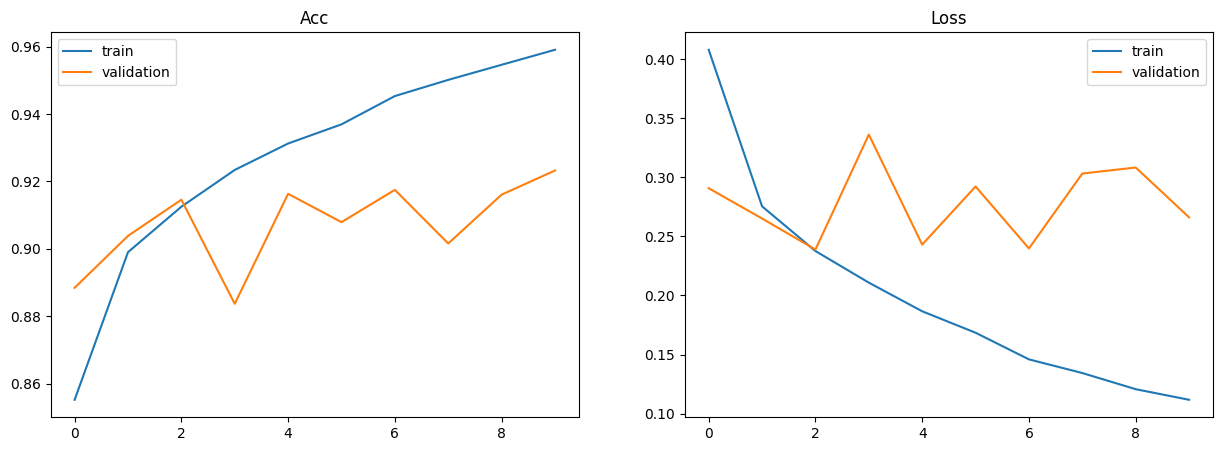

In [33]:
plot_history(history2.history)

In [37]:
model2.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.9188 - loss: 0.3078


[0.30783191323280334, 0.9187999963760376]

## Callback

In [40]:
model3 = models.Sequential()
model3.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)))
model3.add(layers.BatchNormalization())  #과적합 방지
model3.add(layers.MaxPooling2D((2,2), strides=2))
model3.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model3.add(layers.BatchNormalization())
model3.add(layers.MaxPooling2D((2,2), strides=2))
model3.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model3.add(layers.Flatten())
model3.add(layers.Dense(128, activation='relu'))
model3.add(layers.Dropout(0.3))
model3.add(layers.Dense(10, activation='softmax'))
model3.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [41]:
model3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [45]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True) #정확도 가장높은 epoch를 저장
history3 = model3.fit(x_train, y_train, epochs=10, validation_split=0.2, callbacks=[checkpoint_cb])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - acc: 0.8532 - loss: 0.4088 - val_acc: 0.8922 - val_loss: 0.2986
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.8981 - loss: 0.2796 - val_acc: 0.9031 - val_loss: 0.2651
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.9138 - loss: 0.2374 - val_acc: 0.9107 - val_loss: 0.2394
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - acc: 0.9233 - loss: 0.2085 - val_acc: 0.9043 - val_loss: 0.2791
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - acc: 0.9307 - loss: 0.1844 - val_acc: 0.8977 - val_loss: 0.2929
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9386 - loss: 0.1676 - val_acc: 0.9161 - val_loss: 0.2419
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9448 - loss: 0.1475 - val_acc: 0.9143 - val_loss: 0.2626
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9494 - loss: 0.1348 - val_acc: 0.9178 - val_loss: 0.2762
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━

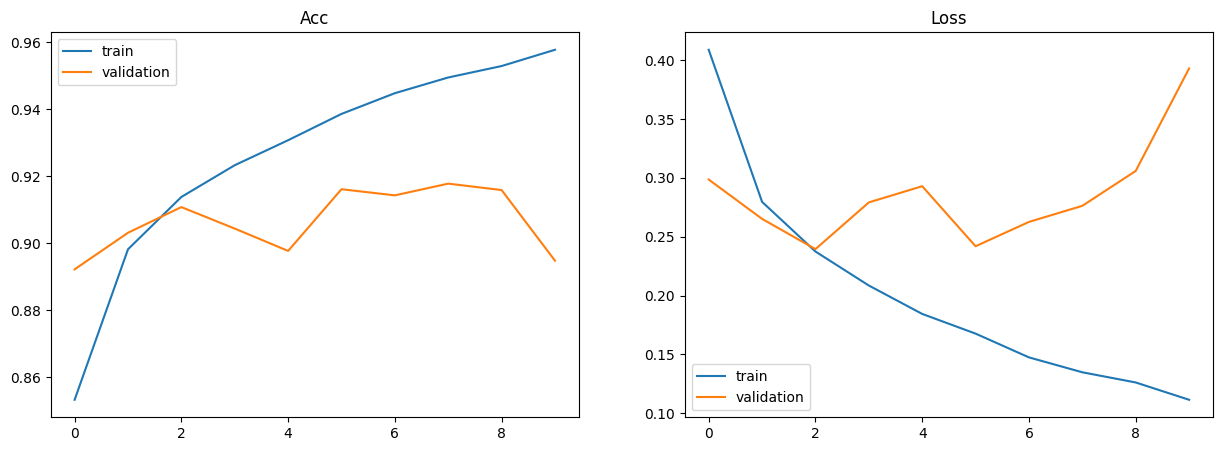

In [56]:
plot_history(history3.history)

In [47]:
model3.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.8897 - loss: 0.4467


[0.4466569423675537, 0.8896999955177307]

In [48]:
model4 = models.Sequential()
model4.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)))
model4.add(layers.BatchNormalization())  #과적합 방지
model4.add(layers.MaxPooling2D((2,2), strides=2))
model4.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model4.add(layers.BatchNormalization())
model4.add(layers.MaxPooling2D((2,2), strides=2))
model4.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model4.add(layers.Flatten())
model4.add(layers.Dense(128, activation='relu'))
model4.add(layers.Dropout(0.3))
model4.add(layers.Dense(10, activation='softmax'))
model4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [52]:
model4.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [55]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history4 = model4.fit(x_train, y_train, epochs=10, validation_split=0.2, callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9318 - loss: 0.1854 - val_acc: 0.9060 - val_loss: 0.2845
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9369 - loss: 0.1691 - val_acc: 0.9197 - val_loss: 0.2362
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - acc: 0.9454 - loss: 0.1429 - val_acc: 0.9194 - val_loss: 0.2616
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9527 - loss: 0.1293 - val_acc: 0.9218 - val_loss: 0.2555
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9555 - loss: 0.1198 - val_acc: 0.9162 - val_loss: 0.2980


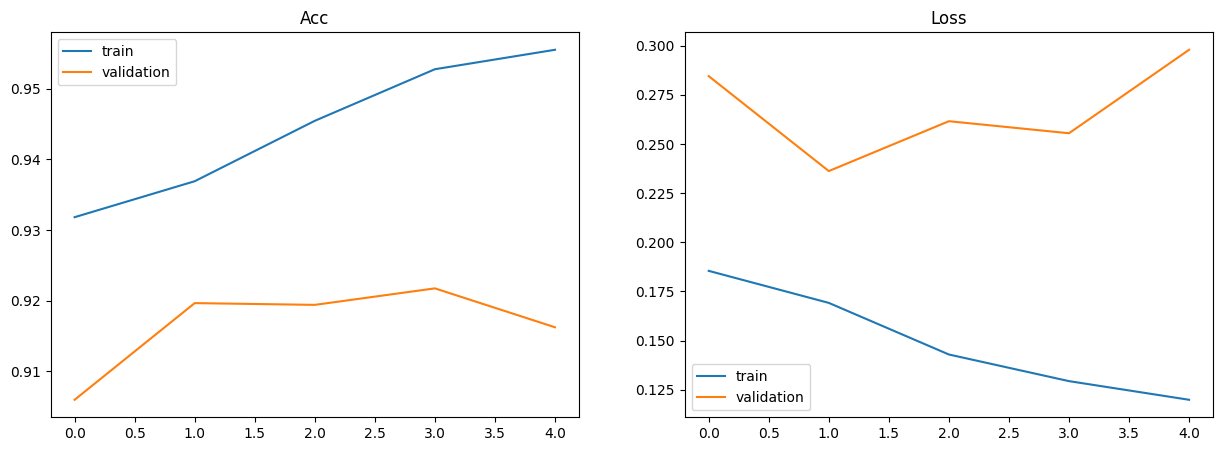

In [57]:
plot_history(history4.history)

In [87]:
pred=model4.predict(x_test[100:125])
print(np.round(pred, decimals=3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[0.    0.    0.    1.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.008 0.    0.992 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.007 0.    0.954 0.    0.    0.    0.04  0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    1.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.759 0.    0.241]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    1.   ]
 [0.    0.    0.    0.    1.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.998 0.    0.    0.    0.002 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.994 0.    0.    0.    0.    0.    0.006 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    1. 

In [88]:
print(np.argmax(pred, axis=1))

[3 6 7 2 7 8 5 7 9 4 2 5 7 0 5 2 8 4 7 8 0 0 9 9 3]


In [91]:
print(y_test[100:125])

[3 6 7 2 7 8 5 9 9 4 2 5 7 0 5 2 8 6 7 8 0 0 9 9 3]


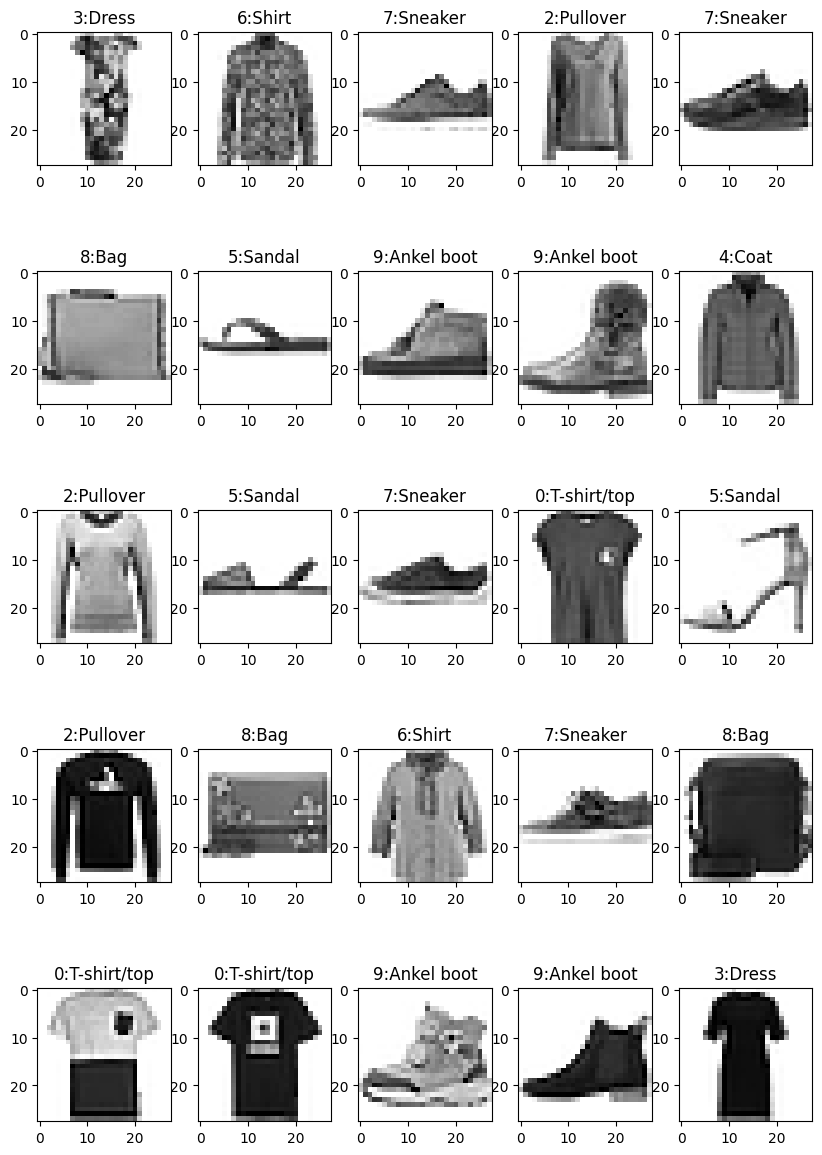

In [92]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_test[i*5+j+100], items[y_test[i*5+j+100]]))
    axs[i, j].imshow(x_test2d[i*5+j+100], cmap='gray_r')
plt.show()

## CNN의 시각화

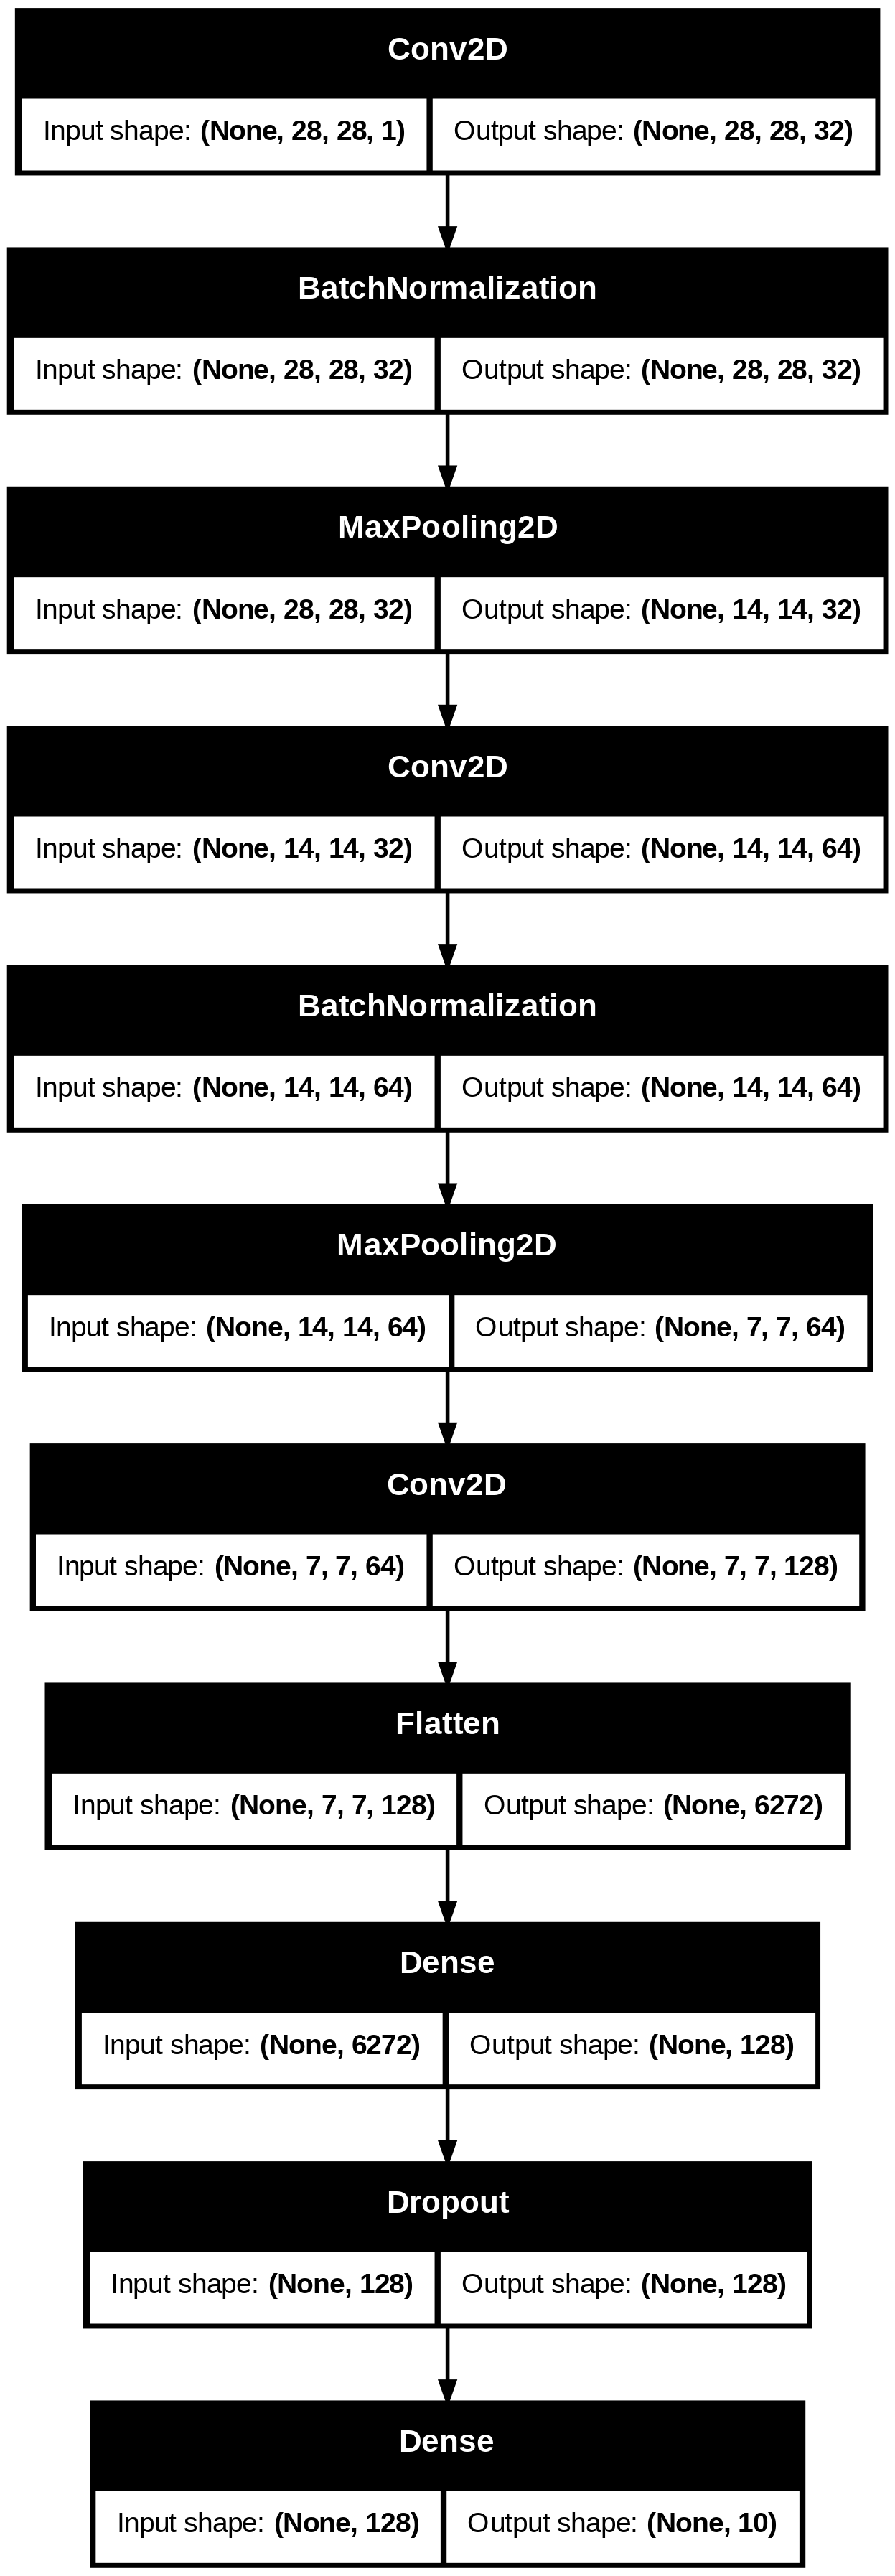

In [93]:
utils.plot_model(model4, show_shapes=True, to_file='fmist.png')

### 학습된 Conv층 가져오기

In [94]:
model4.layers

[<Conv2D name=conv2d_21, built=True>,
 <BatchNormalization name=batch_normalization_6, built=True>,
 <MaxPooling2D name=max_pooling2d_14, built=True>,
 <Conv2D name=conv2d_22, built=True>,
 <BatchNormalization name=batch_normalization_7, built=True>,
 <MaxPooling2D name=max_pooling2d_15, built=True>,
 <Conv2D name=conv2d_23, built=True>,
 <Flatten name=flatten_7, built=True>,
 <Dense name=dense_14, built=True>,
 <Dropout name=dropout_6, built=True>,
 <Dense name=dense_15, built=True>]

In [95]:
conv = model4.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [97]:
weights = conv.weights[0].numpy()
print(weights.shape)
print(weights)

(3, 3, 1, 32)
[[[[-0.13437323 -0.02756046 -0.02515464  0.08866717  0.13082422
     0.05006776 -0.12092914 -0.05893197 -0.18636936 -0.09971648
     0.04609757 -0.2011275  -0.21176542  0.22893012 -0.05416942
    -0.18295108 -0.32406893 -0.02124973 -0.05233883 -0.20748238
    -0.06212396 -0.1457431  -0.22261827 -0.15067215 -0.00785226
    -0.1470515  -0.10201061  0.08958604 -0.04563757  0.28733975
    -0.10401907 -0.11295854]]

  [[-0.05261281 -0.03648559  0.1505417  -0.30766764  0.10063388
     0.15792984 -0.6235983   0.04671002 -0.15276068  0.16021964
     0.15149674 -0.02588703 -0.01422037 -0.13209851  0.14369151
    -0.07926811 -0.05505936  0.0267772  -0.22176059  0.13868912
     0.04345817 -0.22794437  0.03750591  0.15495813 -0.08220664
     0.09128027 -0.00319234 -0.07775013  0.06501602 -0.10853768
    -0.62332094  0.17848009]]

  [[ 0.15754646  0.05472326 -0.03038214  0.11323574 -0.03723316
     0.08224417 -0.59523094 -0.00734975  0.02168949 -0.05728059
    -0.1914122   0.16110863 

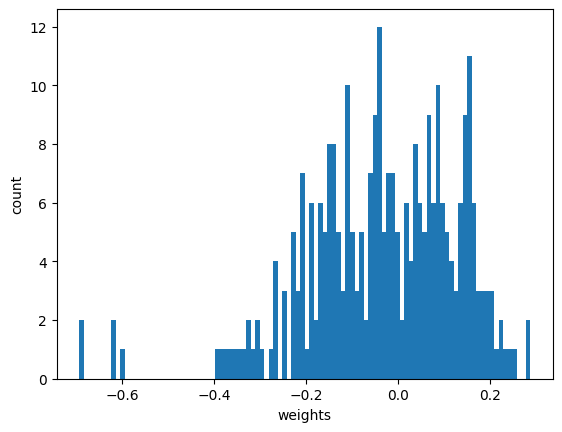

In [98]:
plt.hist(weights.flatten(), bins=100)
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

In [99]:
weights[:,:, 0, 0] #첫번째필터 값, 첫번째 채널 값

array([[-0.13437323, -0.05261281,  0.15754646],
       [-0.07992676, -0.03378958,  0.10489622],
       [ 0.25779128, -0.20712286, -0.06107244]], dtype=float32)

In [100]:
weights[:,:, 0, 1] #두번째필터 값

array([[-0.02756046, -0.03648559,  0.05472326],
       [-0.06378354, -0.22566451,  0.28682575],
       [ 0.06777872, -0.14016211,  0.05874225]], dtype=float32)

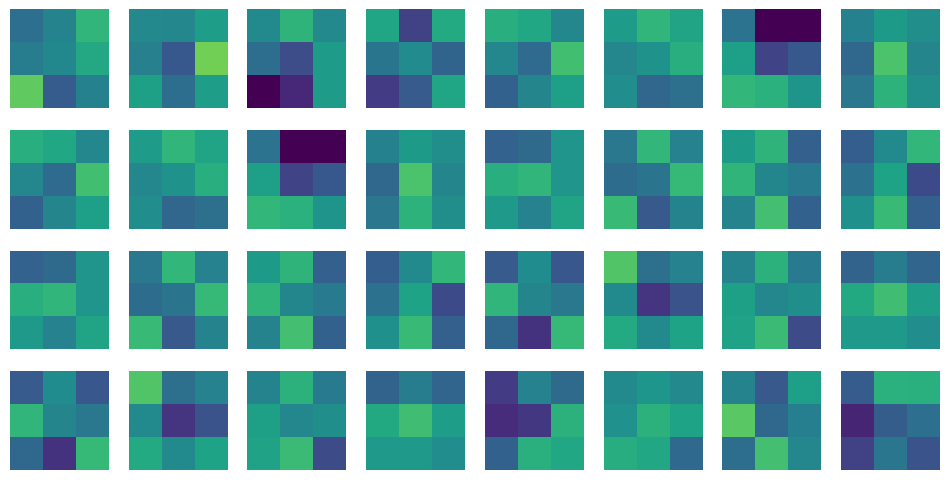

In [104]:
fig, axs = plt.subplots(4, 8, figsize=(12,6)) #학습된 필터
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(weights[:,:,0,i*4+j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')
plt.show()

In [105]:
init_model = keras.Sequential()
init_model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)))
init_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
new_conv = init_model.layers[0]
print(new_conv.weights[0].shape, new_conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [108]:
new_weights = new_conv.weights[0].numpy()
print(new_weights.shape)
print(new_weights)

(3, 3, 1, 32)
[[[[-0.07580961 -0.00953908 -0.08265723 -0.10759713 -0.03994789
     0.05672409  0.06449755 -0.11383829 -0.03403831 -0.12828667
     0.01166087  0.03132817  0.12020014  0.08847684 -0.07924514
    -0.04593772  0.0284553  -0.13386168 -0.03950728  0.09793812
    -0.09630658  0.07373421 -0.1344015   0.01010992 -0.07357549
    -0.12834445  0.01008955  0.10826002  0.00361677 -0.12459502
     0.01487865 -0.00518744]]

  [[ 0.01616351 -0.01196498  0.07921492  0.08910355  0.02962096
     0.05462083 -0.10114809 -0.04633182 -0.03405979  0.1229106
     0.10056078  0.10382432  0.00752896 -0.08915286 -0.06411082
    -0.06269284  0.04770419 -0.07542285  0.04988728  0.08869077
     0.0395892   0.0143764  -0.11020784  0.00297074 -0.02686338
     0.0824824   0.03018121  0.08634831 -0.06512059  0.05148378
     0.05617987 -0.12544014]]

  [[-0.04909961 -0.04899791  0.0226343  -0.05508482  0.07002629
    -0.11008587  0.1028814  -0.04315204 -0.08369167 -0.04001573
     0.05486286  0.02022292  

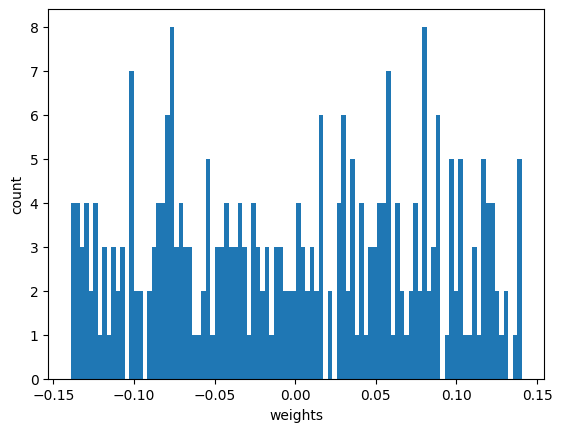

In [109]:
plt.hist(new_weights.flatten(), bins=100)
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

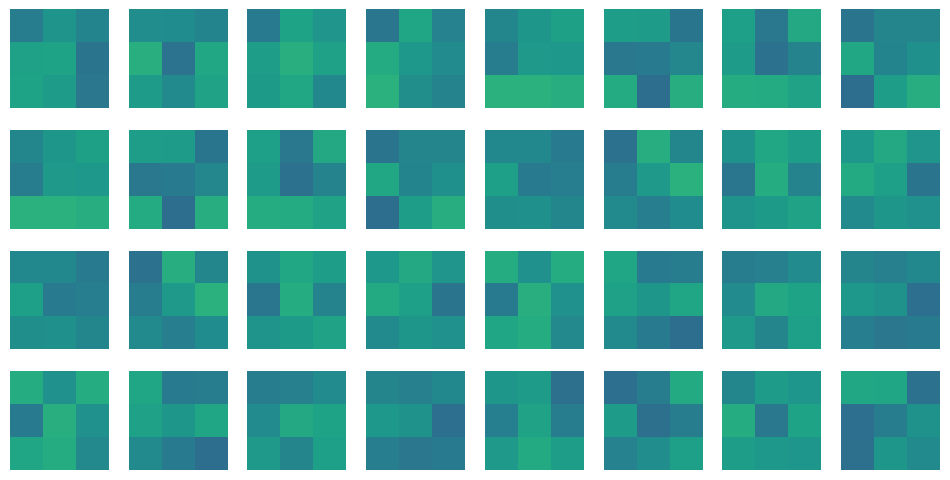

In [110]:
fig, axs = plt.subplots(4, 8, figsize=(12,6)) #학습된 필터
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(new_weights[:,:,0,i*4+j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')
plt.show()

### 필터를 거친 이미지 확인하기

In [112]:
conv1 = keras.Model(model4.inputs[0], model4.layers[0].output)
conv1.summary()

Model: "functional_80"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

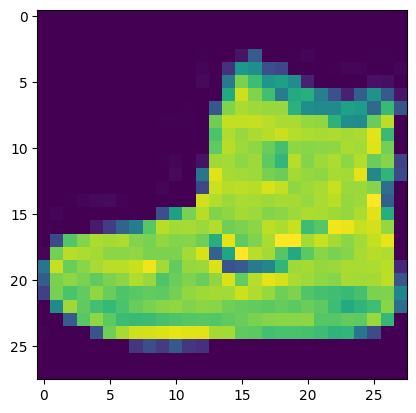

In [113]:
plt.imshow(x_train2d[0])

In [114]:
feature_map1 = conv1.predict(x_train[0:1])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step


In [115]:
print(feature_map1.shape)

(1, 28, 28, 32)


In [117]:
feature_map1[0, :, :, 2]

array([[0.02870493, 0.02870493, 0.02870493, 0.02870493, 0.02870493,
        0.02870493, 0.02870493, 0.02870493, 0.02870493, 0.02870493,
        0.02870493, 0.02870493, 0.02870493, 0.02870493, 0.02870493,
        0.02870493, 0.02870493, 0.02870493, 0.02870493, 0.02870493,
        0.02870493, 0.02870493, 0.02870493, 0.02870493, 0.02870493,
        0.02870493, 0.02870493, 0.02870493],
       [0.02870493, 0.02870493, 0.02870493, 0.02870493, 0.02870493,
        0.02870493, 0.02870493, 0.02870493, 0.02870493, 0.02870493,
        0.02870493, 0.02870493, 0.02870493, 0.02870493, 0.02870493,
        0.02870493, 0.02870493, 0.02870493, 0.02870493, 0.02870493,
        0.02870493, 0.02870493, 0.02870493, 0.02870493, 0.02870493,
        0.02870493, 0.02870493, 0.02870493],
       [0.02870493, 0.02870493, 0.02870493, 0.02870493, 0.02870493,
        0.02870493, 0.02870493, 0.02870493, 0.02870493, 0.02870493,
        0.02870493, 0.02889161, 0.02720174, 0.02598892, 0.03113176,
        0.02279105, 0.    

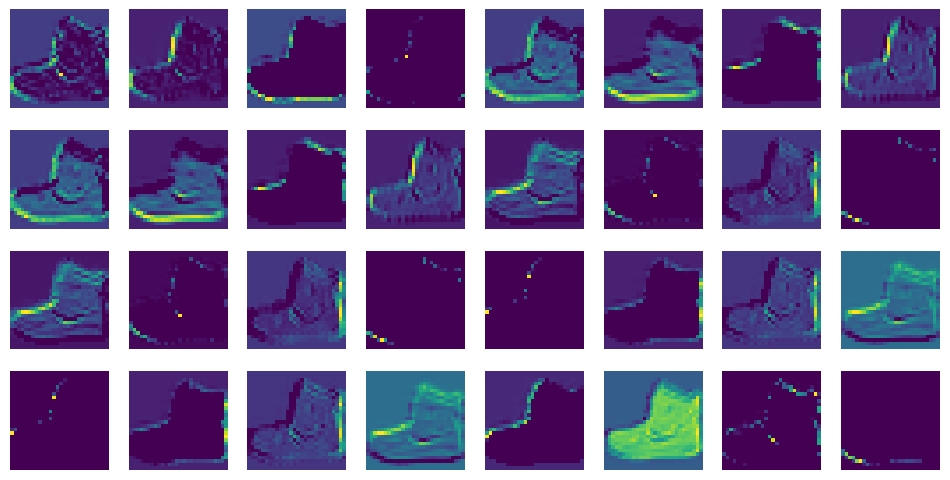

In [120]:
fig, axs = plt.subplots(4, 8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map1[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()

In [121]:
model4.layers

[<Conv2D name=conv2d_21, built=True>,
 <BatchNormalization name=batch_normalization_6, built=True>,
 <MaxPooling2D name=max_pooling2d_14, built=True>,
 <Conv2D name=conv2d_22, built=True>,
 <BatchNormalization name=batch_normalization_7, built=True>,
 <MaxPooling2D name=max_pooling2d_15, built=True>,
 <Conv2D name=conv2d_23, built=True>,
 <Flatten name=flatten_7, built=True>,
 <Dense name=dense_14, built=True>,
 <Dropout name=dropout_6, built=True>,
 <Dense name=dense_15, built=True>]

In [122]:
conv2 = keras.Model(model4.inputs[0], model4.layers[3].output)
conv2.summary()

Model: "functional_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,944 (74.00 KB)

 Trainable params: 18,880 (73.75 KB)

 Non-trainable params: 64 (256.00 B)

In [123]:
feature_map2 = conv2.predict(x_train[0:1])
print(feature_map2.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
(1, 14, 14, 64)


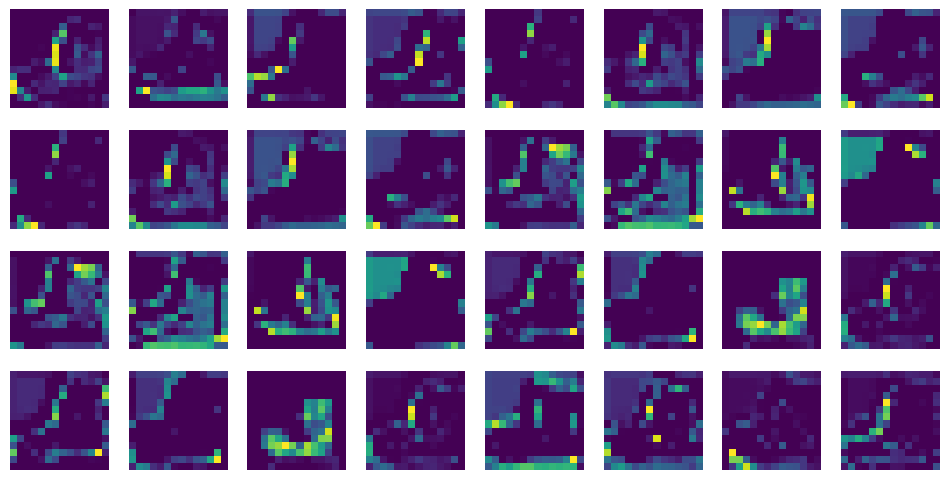

In [124]:
fig, axs = plt.subplots(4, 8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map2[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()

In [125]:
model4.layers

[<Conv2D name=conv2d_21, built=True>,
 <BatchNormalization name=batch_normalization_6, built=True>,
 <MaxPooling2D name=max_pooling2d_14, built=True>,
 <Conv2D name=conv2d_22, built=True>,
 <BatchNormalization name=batch_normalization_7, built=True>,
 <MaxPooling2D name=max_pooling2d_15, built=True>,
 <Conv2D name=conv2d_23, built=True>,
 <Flatten name=flatten_7, built=True>,
 <Dense name=dense_14, built=True>,
 <Dropout name=dropout_6, built=True>,
 <Dense name=dense_15, built=True>]

In [126]:
conv3 = keras.Model(model4.inputs[0], model4.layers[6].output)
conv3.summary()

Model: "functional_82"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,056 (363.50 KB)

 Trainable params: 92,864 (362.75 KB)

 Non-trainable params: 192 (768.00 B)

In [127]:
feature_map3 = conv3.predict(x_train[0:1])
print(feature_map3.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
(1, 7, 7, 128)


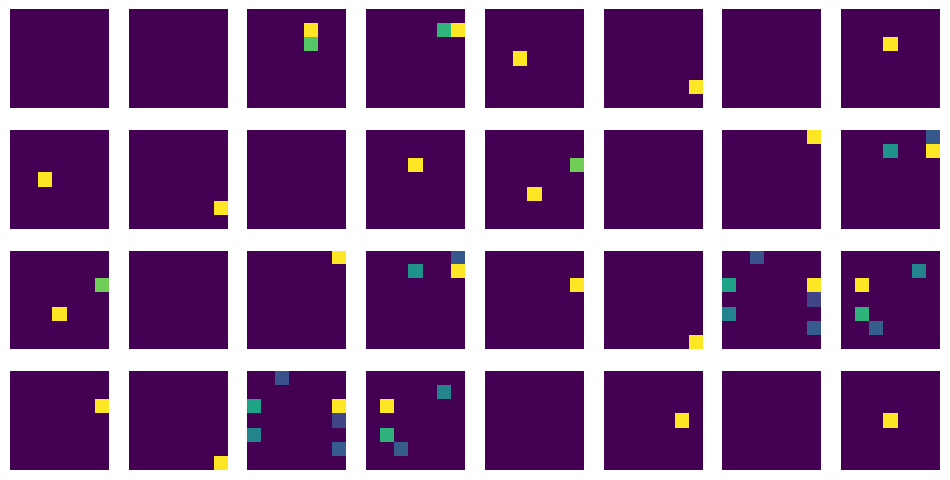

In [128]:
fig, axs = plt.subplots(4, 8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map3[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()